In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


In [27]:
# define a rhs function with no latching that emulates a mass spring system

def eom_mass_spring(t, y, omega, mass, spring_constant, damping_constant, omega_wave):

    # unpack y
    xdot, x = y

    # calculate the periodic force
    force = np.sin(omega * t)

    # define xddot
    xddot = (force - damping_constant * xdot - spring_constant * x) / mass

    return [xddot, xdot]


In [53]:
# solve the mass spring system 

sol_no_latch = solve_ivp(eom_mass_spring, [0, 20], [0.0, 0.0], args=(2.0, 5, 20.0, 20.0, 0.5))


<function matplotlib.pyplot.show(close=None, block=None)>

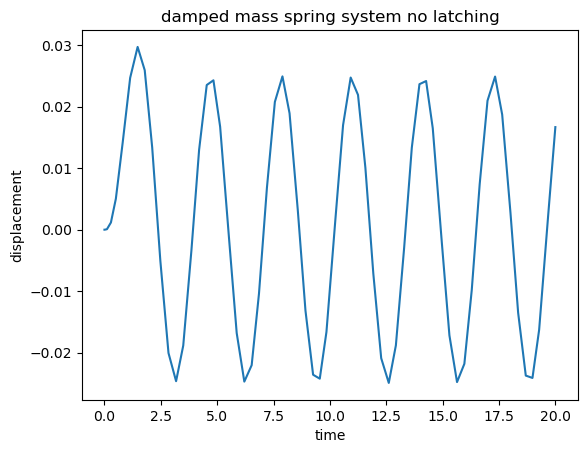

In [54]:
# plot solution

plt.title('damped mass spring system no latching')
plt.plot(sol_no_latch.t, sol_no_latch.y[1])
plt.xlabel('time')
plt.ylabel('displacement')
plt.show

In [55]:
# define a latch event
def latch(t, y, omega, mass, spring_constant, damping_constant, omega_wave): # stops when veolcity becomes zero
    # unpack y
    xdot, x = y
    
    return xdot

'''
when the mass is released from the zero velocity position ie its maximum dispacement it experiences its maximum restoring force.
therefore we want the driving force to also be maximum at the point of release in order to match the phases.
to emulate the damping we can create a new function that is stationary and an event that is dependent on the force being maximum. 
'''

# rhs function for the stationary latched phase
def latched_phase(t, y, omega, mass, spring_constant, damping_constant, omega_wave):
    xddot = xdot = 0 # reset the velocity to zero

    return [xddot, xdot]

# event that detects maximum force
def unlatch(t, y, omega, mass, spring_constant, damping_constant, omega_wave):

    # force is maxumum when we have cos(n*pi) = 0

    return np.cos(omega * t) 

unlatch.terminal = True
unlatch.direction = 0




intial run with no event complete. ended at t = 0.01
entering while loop starting with mass spring phase
latch event detected at t = [array([1.49539437])]
entering latched phase
unlatch event detected at t = [array([2.35619449])]
latch event detected at t = [array([3.37542545])]
entering latched phase
unlatch event detected at t = [array([3.92699082])]
latch event detected at t = [array([4.8019061])]
entering latched phase
unlatch event detected at t = [array([5.49778714])]
latch event detected at t = [array([6.43953048])]
entering latched phase
unlatch event detected at t = [array([7.06858347])]
latch event detected at t = [array([7.98071268])]
entering latched phase
unlatch event detected at t = [array([8.6393798])]
latch event detected at t = [array([9.56492135])]
entering latched phase
unlatch event detected at t = [array([10.21017612])]
latch event detected at t = [array([11.12969984])]
entering latched phase
unlatch event detected at t = [array([11.78097245])]
latch event detecte

<function matplotlib.pyplot.show(close=None, block=None)>

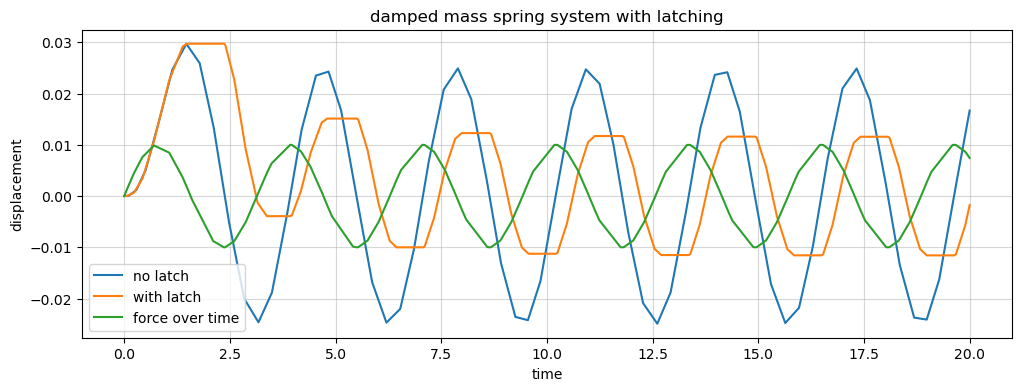

In [57]:
# solve with events 

# set timespan
t_span = (0, 20)

# create storage of values

t_last = 0.0
x_last = 0.0
xdot_last = 0.0

t = []
x = []
xdot = []


# spring phase
sol = solve_ivp(eom_mass_spring, [t_last, 1e-2], [xdot_last, x_last], args=(2.0, 5, 20.0, 20.0, 1.5), max_step=0.5)
# append results to lists
t.extend(sol.t.tolist()) # extend adds the element to the existing array rather than making the list multid dimensional
xdot.extend(sol.y[0].tolist())
x.extend(sol.y[1].tolist())

t_last = sol.t[-1]
xdot_last = sol.y[0][-1]
x_last = sol.y[1][-1]

print(f'intial run with no event complete. ended at t = {t_last}')


print(f'entering while loop starting with mass spring phase')


while t_last < t_span[-1]:

    '''----------------------------spring phase ----------------------------------------'''

    # set the event detection
    latch.terminal = True
    latch.direction = -1

    # spring phase
    sol = solve_ivp(eom_mass_spring, [t_last, t_span[-1]], [xdot_last, x_last], events=latch, args=(2.0, 5, 20.0, 20.0, 1.5), max_step=0.5)

    # append results to lists
    t.extend((sol.t[1:]).tolist()) # extend adds the element to the existing array rather than making the list multid dimensional
    xdot.extend(sol.y[0][1:].tolist())
    x.extend(sol.y[1][1:].tolist())
    

    t_last = sol.t[-1]
    xdot_last = sol.y[0][-1]
    x_last = sol.y[1][-1]
    print(f'latch event detected at t = {sol.t_events}')

    '''----------------------------latched phase ----------------------------------------'''

    print(f'entering latched phase')
    # latch phase
    sol = solve_ivp(latched_phase, [t_last, t_span[-1]], [xdot_last, x_last], events=unlatch, args=(2.0, 5, 20.0, 20.0, 1.5), max_step=0.5)

    # append results to lists
    t.extend((sol.t[1:]).tolist())
    xdot.extend(sol.y[0][1:].tolist())
    x.extend(sol.y[1][1:].tolist())

    t_last = sol.t[-1]
    xdot_last = sol.y[0][-1]
    x_last = sol.y[1][-1]

    print(f'unlatch event detected at t = {sol.t_events}')

    '''----------------------------spring phase ----------------------------------------'''

    # set the event detection
    latch.terminal = True
    latch.direction = 1

    # spring phase
    sol = solve_ivp(eom_mass_spring, [t_last, t_span[-1]], [xdot_last, x_last], events=latch, args=(2.0, 5, 20.0, 20.0, 1.5), max_step=0.5)

    # append results to lists

    t.extend((sol.t[1:]).tolist()) # extend adds the element to the existing array rather than making the list multid dimensional
    xdot.extend(sol.y[0][1:].tolist())
    x.extend(sol.y[1][1:].tolist())

    t_last = sol.t[-1]
    xdot_last = sol.y[0][-1]
    x_last = sol.y[1][-1]
    print(f'latch event detected at t = {sol.t_events}')

    '''----------------------------latched phase ----------------------------------------'''

    print(f'entering latched phase')
    # latch phase
    sol = solve_ivp(latched_phase, [t_last, t_span[-1]], [xdot_last, x_last], events=unlatch, args=(2.0, 5, 20.0, 20.0, 1.5), max_step=0.5)

    # append results to lists

    t.extend((sol.t[1:]).tolist())
    xdot.extend(sol.y[0][1:].tolist())
    x.extend(sol.y[1][1:].tolist())

    t_last = sol.t[-1]
    xdot_last = sol.y[0][-1]
    x_last = sol.y[1][-1]

    print(f'unlatch event detected at t = {sol.t_events}')


'''----------------------------plot results ----------------------------------------'''

print('simulation ended.')
print('plotting results')

# plot results

plt.figure(figsize=(12, 4))
plt.title('damped mass spring system with latching')
plt.plot(sol_no_latch.t, sol_no_latch.y[1], label='no latch')
plt.plot(t, x, label='with latch')
plt.plot(t, 1e-2 * np.sin(2.0 * np.array(t)), label='force over time')
plt.xlabel('time')
plt.ylabel('displacement')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show
